
# 02 — Risk-aware allocation

Forecasting `Gbps` is not provisioning. This notebook builds the decision layer the
project's title promises.

**The cost model.** For an allocation `A` against realised demand `y`:

$$C = c_{over}\,(A-y)^+ + \kappa\,c_{over}\,(y-A)^+$$

Under-provisioning costs κ times more than over-provisioning. The cost-minimising
allocation is then not the mean but the **τ-quantile** of the predictive
distribution, with

$$\tau^* = \frac{\kappa}{1+\kappa}$$

So the operator's cost ratio *selects the quantile*. κ = 10 → τ = 0.909.

In [1]:
# --- Bootstrap: works locally and on Colab ---------------------------------
# Locally this just finds the repository root. On Colab the repo is not on the VM
# yet, so it is cloned first. The repository is PRIVATE, which means the clone
# needs a GitHub token -- put one in Colab Secrets (the key icon in the left
# sidebar) under the name GH_TOKEN and enable notebook access. See docs/COLAB.md.
import os, sys, warnings
from pathlib import Path

warnings.filterwarnings("ignore")
REPO = "github.com/sad-code-at/bwalloc.git"

ROOT = Path.cwd()
while not (ROOT / "src" / "bwalloc").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent

if not (ROOT / "src" / "bwalloc").exists():
    target = Path("/content/bwalloc")
    if not (target / "src" / "bwalloc").exists():
        try:
            from google.colab import userdata
            token = userdata.get("GH_TOKEN")
        except Exception:
            token = None
        if not token:
            raise SystemExit(
                "Could not find the repository, and no GH_TOKEN is available. "
                "On Colab: add a GitHub token in Secrets (the key icon) as "
                "GH_TOKEN, enable notebook access for this notebook, and re-run "
                "-- see docs/COLAB.md. Locally: run this notebook from inside "
                "the repository."
            )
        # The token never reaches stdout: git is quiet and errors are sanitised.
        rc = os.system(f"git clone -q https://{token}@{REPO} {target} 2>/dev/null")
        if rc != 0 or not (target / "src" / "bwalloc").exists():
            raise SystemExit(
                "git clone failed. Check that GH_TOKEN is valid, not expired, and "
                "has read access to this repository (Contents: Read)."
            )
    os.chdir(target)
    ROOT = target

sys.path.insert(0, str(ROOT / "src"))

try:
    import xgboost  # noqa: F401
except ImportError:
    !pip install -q xgboost

import numpy as np, pandas as pd, matplotlib.pyplot as plt
import bwalloc as bw
from bwalloc.plots import use_paper_style

bw.set_seed()
use_paper_style()
pd.set_option("display.width", 200)
RESULTS = ROOT / "experiments" / "results"
# Scratch output for the exploratory notebooks. Only 07_paper_figures writes into
# paper/figures -- otherwise running notebook 00 or 05 silently overwrites a figure
# the paper cites, which is exactly the kind of drift this project exists to remove.
FIGURES = ROOT / "notebooks" / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)
print("bwalloc", bw.__version__, "| results:", RESULTS)

bwalloc 0.1.0 | results: D:\L4-T-1\EEE 402\project\bwalloc\experiments\results


In [2]:

from bwalloc.allocation import kappa_for_tau, optimal_tau

for kappa in (2, 5, 10, 20):
    print(f"kappa={kappa:2d}  ->  tau* = {optimal_tau(kappa):.4f}")
print()
# And the correspondence verified empirically rather than asserted:
rng = np.random.default_rng(0)
y = rng.gamma(shape=9, scale=10, size=200_000)
for kappa in (2, 10):
    grid = np.linspace(np.quantile(y, 0.4), np.quantile(y, 0.995), 400)
    costs = [np.mean(np.maximum(a - y, 0) + kappa * np.maximum(y - a, 0)) for a in grid]
    empirical = grid[int(np.argmin(costs))]
    print(f"kappa={kappa:2d}: cost-minimising allocation {empirical:7.2f}  "
          f"vs quantile at tau* {np.quantile(y, optimal_tau(kappa)):7.2f}")

kappa= 2  ->  tau* = 0.6667
kappa= 5  ->  tau* = 0.8333
kappa=10  ->  tau* = 0.9091
kappa=20  ->  tau* = 0.9524



kappa= 2: cost-minimising allocation   99.99  vs quantile at tau*  100.06


kappa=10: cost-minimising allocation  132.05  vs quantile at tau*  132.05


## Conformal calibration

A quantile model that claims 95% rarely delivers 95%. Split conformal fixes that distribution-free — which matters precisely because there are only ~900 points and no parametric error model is credible.

In [3]:

from bwalloc.context import assign_binary_groups
from bwalloc.data import load, sampling_profile
from bwalloc.features import FeatureConfig, build_features
from bwalloc.models import xgboost_point
from bwalloc.pipeline import coverage_table, run_allocation_backtest
from bwalloc.splits import rolling_origin

OPERATOR = "gp"
df = load(OPERATOR)
profile = sampling_profile(df)
X, y = build_features(df, profile, FeatureConfig())
groups = assign_binary_groups(df).reindex(X.index)
folds = rolling_origin(len(y), n_folds=8, calib_frac=0.30)

per_fold, allocations = run_allocation_backtest(
    X, y, folds, groups, model_factory=xgboost_point, taus=(0.80, 0.90, 0.95),
)
coverage_table(per_fold[per_fold["group"] == "ALL"], "coverage")

method,tau,group,aci,adaptive,marginal,mondrian
0,0.80,ALL,0.804878,0.801126,0.786116,0.780488
1,0.90,ALL,0.902439,0.874296,0.866792,0.870544
2,0.95,ALL,0.953096,0.930582,0.930582,0.939962



### Coverage is systematically short — and that is a finding

Achieved coverage lands *below* nominal almost everywhere, and the shortfall is
one-sided. That is the signature of exchangeability failing under temporal drift, not
of a bug: split conformal's finite-sample guarantee is conditional on exchangeability,
and a 55-day trace with a trend does not supply it.

`experiments/run_coverage_gate.py` quantifies it across every configuration.
`conformal.AdaptiveConformalInference` is the remedy — it updates the requested level
online from realised breaches, so long-run coverage converges without assuming
exchangeability at all. The `aci` row above is that method.

In [4]:

gate = pd.read_csv(RESULTS / "coverage_gate.csv")
marginal = gate[(gate["group"] == "ALL") & (gate["operator"] == OPERATOR)]
marginal[["horizon_hours", "tau", "method", "n", "coverage", "gap", "passes", "decisive"]]

,horizon_hours,tau,method,n,coverage,gap,passes,decisive
0,1.5,0.80,aci,533,0.803002,0.003002,True,False
3,1.5,0.80,adaptive,533,0.784240,-0.015760,True,False
6,1.5,0.80,marginal,533,0.784240,-0.015760,True,False
9,1.5,0.80,mondrian,533,0.776735,-0.023265,False,False
12,1.5,0.90,aci,533,0.904315,0.004315,True,False
15,1.5,0.90,adaptive,533,0.863039,-0.036961,False,True
18,1.5,0.90,marginal,533,0.866792,-0.033208,False,True
21,1.5,0.90,mondrian,533,0.853659,-0.046341,False,True
24,1.5,0.95,aci,533,0.947467,-0.002533,True,False
27,1.5,0.95,adaptive,533,0.919325,-0.030675,False,True


## The capacity–risk frontier

The headline comparison: the calibrated allocator against the fixed-margin rule operators actually use (`A = 1.3 × ŷ`), plus static peak allocation. Read it as *capacity required at an equal SLA violation rate*.

,target_violation,alloc_a,alloc_b,capacity_saving,feasible,operator,family,setting_a,setting_b
0,0.01,NaN,1.402667,NaN,False,gp,conformal_relative,NaN,NaN
1,0.02,NaN,1.302476,NaN,False,gp,conformal_relative,NaN,NaN
2,0.05,NaN,1.302476,NaN,False,gp,conformal_relative,NaN,NaN
3,0.10,1.188466,1.152191,-0.031484,True,gp,conformal_relative,0.95,0.15
4,0.01,NaN,1.402667,NaN,False,gp,conformal_adaptive,NaN,NaN
5,0.02,NaN,1.302476,NaN,False,gp,conformal_adaptive,NaN,NaN
6,0.05,NaN,1.302476,NaN,False,gp,conformal_adaptive,NaN,NaN
7,0.10,1.175013,1.152191,-0.019807,True,gp,conformal_adaptive,0.95,0.15
8,0.01,NaN,1.402667,NaN,False,gp,conformal_marginal,NaN,NaN
9,0.02,NaN,1.302476,NaN,False,gp,conformal_marginal,NaN,NaN


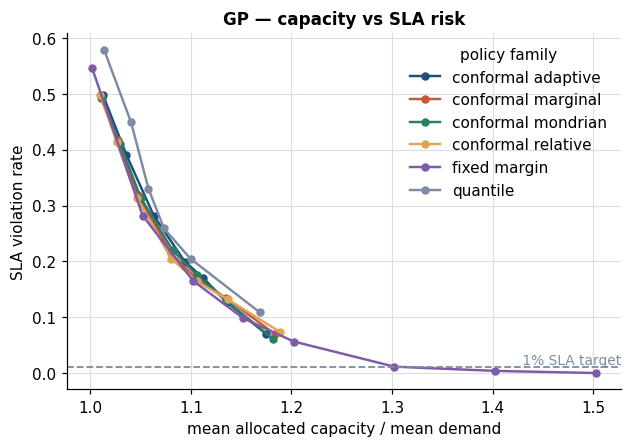

In [5]:

from bwalloc.plots import plot_pareto

pareto = pd.read_csv(RESULTS / f"pareto_{OPERATOR}.csv")
fig, ax = plt.subplots(figsize=(6.5, 4.2))
plot_pareto(pareto, ax=ax)
ax.set_title(f"{OPERATOR.upper()} — capacity vs SLA risk")
fig.savefig(FIGURES / f"fig3_pareto_{OPERATOR}.png", dpi=200, bbox_inches="tight")

pd.read_csv(RESULTS / f"savings_{OPERATOR}.csv")


### Honest reading of the frontier

**The capacity-saving claim does not hold on these traces.** No conformal family
reaches a 1%, 2% or 5% violation target, and at the targets that are feasible the
saving against fixed-margin is negative or negligible.

The reason is structural and worth stating: the fixed-margin rule is *multiplicative*
(`A = 1.3 ŷ`) while additive conformal adds the same number of Gbps at 3 a.m. as at
peak. On a series whose level swings ~2× within a day that is a real handicap. The
`conformal_relative` family removes the confound by calibrating a percentage margin
instead — that is the like-for-like comparison, and it is the row to read.